In [2]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import wait
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd
import dask.array as da
import dask.bag as d
import graphviz
import pandas as pd
import numpy as np
import itertools
from time import time
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging
import seaborn as sns
import os
import json

In [3]:
## >> xx selects rotates bits to the right by xx places
@dask.delayed
def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head==2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [4]:
def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i select [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [5]:
# This fuction:
# - assigns the chamber number to each event
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - consider only events with more than 4 and less than num_hits chamber hits per orbit (4 are usually needed to pass the 4 detector layers, if less it is very likely noise) 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time

def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)
    
    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
     
    df = df[df["CHAN"]<=127] # remove info about the scintillator

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[(chamber_counts["hits_count"]<=num_hits)&(chamber_counts["hits_count"]>=4)][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [6]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)

def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber w.r.t. to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]// 2 * 21.
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13.

    df["drift"]= df["T_REL"]*53.8*0.001
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [7]:
def fit_chamber_vectorized(df_ch):
    if len(df_ch) < 3:
        return None
    
    x_left = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values
    z_vals = df_ch["z"].values
    N = len(x_left)

    # generate all left/right combinations (2^N x N)
    choices = np.array(list(itertools.product([0, 1], repeat=N)))
    
    # create candidate x positions for each combination
    x_matrix = np.where(choices == 0, x_left, x_right)  # shape (2^N, N)

    # fit lines and compute residuals in vectorized form
    
    z_matrix = np.tile(z_vals, (2**N, 1))  # repeat y_vals for each combination

    # linear regression by hand: x = m*y + q
    z_mean = z_matrix.mean(axis=1)
    x_mean = x_matrix.mean(axis=1)
    m = np.sum((z_matrix - z_mean[:, None]) * (x_matrix - x_mean[:, None]), axis=1) / np.sum((z_matrix - z_mean[:, None])**2, axis=1)
    q = x_mean - m * z_mean
    resid = np.sum((x_matrix - (m[:, None]*z_matrix + q[:, None]))**2, axis=1)
  
    N = z_vals.shape[0]       # number of hits
    ndof = max(N-2, 1)        # degrees of freedom (avoid div by 0)
    chi_sq = resid /ndof

    best_idx = np.argmin(chi_sq)
    best = {
    "m": m[best_idx],
    "q": q[best_idx],
    "χ²/ndof": chi_sq[best_idx],
    "x_best": x_matrix[best_idx],
    "z_vals": z_vals}
    
    return best



def process_partition(df):
    results = []
    for (orbit, chamber_id), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        best = fit_chamber_vectorized(df_grp)
        if best is not None:
            results.append({
                "ORBIT": orbit,
                "CHAMBER": chamber_id,
                "m": best["m"],
                "q": best["q"],
                "χ²/ndof": best["χ²/ndof"],
                "x_best": best["x_best"],
                "z_vals": best["z_vals"]} )
            
    return pd.DataFrame(results)


 # we need to explicitly tell Dask what the output schema of the df will be

meta = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "CHAMBER": pd.Series(dtype="int64"),
    "m": pd.Series(dtype="float64"),
    "q": pd.Series(dtype="float64"),
    "χ²/ndof": pd.Series(dtype="float64"),
    "x_best": pd.Series(dtype="object"),  # lists/arrays stored as objects
    "z_vals": pd.Series(dtype="object")
})
    

In [8]:
def fit_global(df_orbit):
    """
    df_orbit: DataFrame with local fit results for chambers 0,2,3
              and a single ORBIT. It needs to contain columns 'CHAMBER', 'x_best', 'z_vals'. """
    # Consider only chambers 0,2,3
    df_sel = df_orbit[df_orbit["CHAMBER"].isin([0,2,3])]
    if len(df_sel) < 2:
        return None  # troppo poche camere per un fit globale

    # Concatenate all x_best e z_vals of 
    x_all = np.concatenate(df_sel["x_best"].values)
    z_all = np.concatenate(df_sel["z_vals"].values)
    
    # Global linear fit (least squares)
    z_mean = np.mean(z_all)
    x_mean = np.mean(x_all)
    
    m = np.sum((z_all - z_mean)*(x_all - x_mean))/np.sum((z_all - z_mean)**2)
    q = x_mean - m*z_mean
    
    resid = np.sum((x_all - (m*z_all + q))**2)
    ndof = len(x_all)-2
    chi_sq = resid / ndof
    
    return {
        "m_global": m,
        "q_global": q,
        "χ²/ndof_global": chi_sq,
        "x_all": x_all,
        "z_all": z_all
    }

def process_partition_global(df_fit_local):
    results = []
    for orbit, df_grp in df_fit_local.groupby("ORBIT"):
        df_pass = df_grp[["CHAMBER", "x_best", "z_vals"]]
        best_global = fit_global(df_pass)
        if best_global is not None:
            results.append({
                "ORBIT": orbit,
                **best_global })
    return pd.DataFrame(results)

# Schema Dask per il fit globale
meta_global = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "m_global": pd.Series(dtype="float64"),
    "q_global": pd.Series(dtype="float64"),
    "χ²/ndof_global": pd.Series(dtype="float64"),
    "x_all": pd.Series(dtype="object"),
    "z_all": pd.Series(dtype="object")
})

In [9]:

def compute_ang_res(fit_results, global_fit_results, chi2_cut=2.8):
    """
    Compute angular resolution of single chamber comparing the slope of local fit in chamber 2 vs global fit slope
    Apply a cut on the global fit χ²/ndof value to choose which events consider as trust-worthy (default=2.8) """

    fit_results_2 = fit_results[fit_results['CHAMBER'] == 2]

    # merge the local and global fit results on common orbits
    merged = fit_results_2.merge(
    global_fit_results,
    on="ORBIT",
    how="inner")

    compare_results = merged[merged['χ²/ndof_global'] < chi2_cut]

    ang_diff = compare_results.copy()
    ang_diff['ang_diff'] = np.degrees(np.arctan(ang_diff["m"] - ang_diff["m_global"]))
    ang_diff = ang_diff[['ORBIT', 'χ²/ndof_global', 'm', 'm_global', 'ang_diff']]

    # resolution estimate
    ang_res = np.abs(ang_diff['ang_diff']).mean()
    err = ang_diff['ang_diff'].std()/len(ang_diff)**0.5

    return ang_res, err, ang_diff

In [10]:
def benchmark(num_workers,num_threads,num_partitions):
    
    cluster = SSHCluster(
    ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
    worker_options={"nthreads": num_threads, "n_workers": num_workers, "memory_limit": "auto"},
    scheduler_options={"host": "10.67.22.48","port":0, "dashboard_address": ":40973"},
    connect_options={
    "known_hosts": None,
    "client_keys": "cluster_key"})

    client = Client(cluster)
    
    benchmarking_results = { "workers": num_workers,
        "threads": num_threads,
        "partitions": num_partitions}

    t_0 = time()
    df = read_file("s3://project-bkp/data_00000*") # use all files
    df = df.repartition(npartitions=num_partitions) # define a different number of partitions
    
    # first processing runtime
    start = time()
    new_df = df.map_partitions(first_processing,num_hits=25).persist()
    wait(new_df)
    benchmarking_results["first_processing"] = time()-start

    # coordiantes computation runtime
    start= time()
    df_processed = new_df.map_partitions(compute_coordinates).persist()
    wait(df_processed)
    benchmarking_results["hit_coordinates_computation"] = time()-start

    # local track fit runtime
    start= time()
    df_local_fit = df_processed.map_partitions(process_partition,meta=meta).persist()
    wait(df_local_fit)
    benchmarking_results["local_fit"] = time()-start

    # global track fit runtime
    start= time()
    df_global_fit = df_local_fit.map_partitions(process_partition_global,meta=meta_global).persist()
    wait(df_global_fit)
    benchmarking_results["global_fit"] = time()-start

    # angular resolution estimate runtime
    start= time()
    _,_,ang_diff= compute_ang_res(df_local_fit,df_global_fit)
    ang_diff = ang_diff.persist()
    wait(ang_diff)
    benchmarking_results["angular_resolution"] = time()-start

    benchmarking_results["total_wall_time"] = time()-t_0

    
    client.close()
    cluster.close()
    
    return(benchmarking_results)


In [11]:
def benchmark_less_VMs(num_threads,num_partitions,single_VM):
    
    # here use just a single VM and a single worker for the cluster 
    if single_VM==True:
        cluster_workers=1
        cluster = SSHCluster(
        ["10.67.22.48", "10.67.22.48"],
        worker_options={"nthreads": num_threads, "n_workers": 1, "memory_limit": "auto"},
        scheduler_options={"host": "10.67.22.48","port":0, "dashboard_address": ":40973"},
        connect_options={
        "known_hosts": None,
        "client_keys": "cluster_key"})
        
    # here use two VMs and two workers for the cluster 
    else:
        cluster_workers=2
        cluster = SSHCluster(
        ["10.67.22.48","10.67.22.48","10.67.22.45"],
        worker_options={"nthreads": num_threads, "n_workers": 1, "memory_limit": "auto"},
        scheduler_options={"host": "10.67.22.48","port":0, "dashboard_address": ":40973"},
        connect_options={
        "known_hosts": None,
        "client_keys": "cluster_key"})

    client = Client(cluster)
    
    benchmarking_results = { "cluster_workers": cluster_workers,
        "threads": num_threads,
        "partitions": num_partitions}

    t_0 = time()
    df = read_file("s3://project-bkp/data_00000*") # use all files
    df = df.repartition(npartitions=num_partitions) # define a different number of partitions
    
    # first processing runtime
    start = time()
    new_df = df.map_partitions(first_processing,num_hits=25).persist()
    wait(new_df)
    benchmarking_results["first_processing"] = time()-start

    # coordiantes computation runtime
    start= time()
    df_processed = new_df.map_partitions(compute_coordinates).persist()
    wait(df_processed)
    benchmarking_results["hit_coordinates_computation"] = time()-start

    # local track fit runtime
    start= time()
    df_local_fit = df_processed.map_partitions(process_partition,meta=meta).persist()
    wait(df_local_fit)
    benchmarking_results["local_fit"] = time()-start

    # global track fit runtime
    start= time()
    df_global_fit = df_local_fit.map_partitions(process_partition_global,meta=meta_global).persist()
    wait(df_global_fit)
    benchmarking_results["global_fit"] = time()-start

    # angular resolution estimate runtime
    start= time()
    _,_,ang_diff= compute_ang_res(df_local_fit,df_global_fit)
    ang_diff = ang_diff.persist()
    wait(ang_diff)
    benchmarking_results["angular_resolution"] = time()-start

    benchmarking_results["total_wall_time"] = time()-t_0

    
    client.close()
    cluster.close()
    
    return(benchmarking_results)

We have at most 16 CPUs in the cluster, so we expect CPU oversubscription with num_workers x num_threads > 16 (OS will time-slice threads, constantly switching between them). 

In [ ]:
import os 
import json


single_VM = [True,False] # this is the number of workers per host! actual number of workers of the cluster is then 3*workers 
threads = [1,2,4,8,16] 
partitions = [2,4,8,16,32,64,128,256,512,1024] # with 1 partition the df does not fit in memory, so computation is impossible


os.makedirs("Benchmarking",exist_ok=True)

for hp in single_VM:
    for num_threads in threads:
        for num_partitions in partitions:
            cluster_workers= 1 if hp==True else 2
            print(f"Performing benchmarking with {cluster_workers} cluster workers, {num_threads} threads, {num_partitions} partitions")
            filename= f"Benchmarking/results_{cluster_workers}clusterworkers_{num_threads}threads_{num_partitions}partitions.json" 
             # skip that computation if file already exists
            if os.path.exists(filename):
                print(f"Skipping {filename}, already exists \n")
                continue
            try:
             res = benchmark_less_VMs(num_threads,num_partitions,single_VM=hp)
            except Exception as e:
                print(f"Error with the combination clsuter_workers={cluster_workers}, threads={num_threads}, partitions={num_partitions}: {e}\n")
                continue 
            with open(filename,'w') as file:
                json.dump(res,file) # store in files not to lose partial results in case of problems during the cycle
            print(f"Total wall time {res['total_wall_time']} s","\n")


Performing benchmarking with 1 cluster workers, 1 threads, 2 partitions


2025-08-28 15:09:04,959 - distributed.deploy.ssh - INFO - /home/ubuntu/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 40973 is already in use.
2025-08-28 15:09:04,965 - distributed.deploy.ssh - INFO - Perhaps you already have a cluster running?
2025-08-28 15:09:04,966 - distributed.deploy.ssh - INFO - Hosting the HTTP server on port 44875 instead
2025-08-28 15:09:04,967 - distributed.deploy.ssh - INFO - warnings.warn(
2025-08-28 15:09:04,998 - distributed.deploy.ssh - INFO - 2025-08-28 15:09:04,997 - distributed.scheduler - INFO - State start
2025-08-28 15:09:05,014 - distributed.deploy.ssh - INFO - 2025-08-28 15:09:05,013 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.48:42221
2025-08-28 15:09:06,949 - distributed.deploy.ssh - INFO - 2025-08-28 15:09:06,944 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:42827'
2025-08-28 15:09:08,777 - distributed.deploy.ssh - INFO - 2025-08-28 15:09:08,761 - distributed.worke

In [ ]:
import os 
import json


workers = [1,2,3,4] # this is the number of workers per host! actual number of workers of the cluster is then 3*workers 
threads = [1,2,4,8,16] 
partitions = [2,4,8,16,32,64,128,256,512,1024] # with 1 partition the df does not fit in memory, so computation is impossible


os.makedirs("Benchmarking",exist_ok=True)

for num_workers in workers:
    for num_threads in threads:
        for num_partitions in partitions:
            print(f"Performing benchmarking with {num_workers} workers, {num_threads} threads, {num_partitions} partitions")
            filename= f"Benchmarking/results_{num_workers}workers_{num_threads}threads_{num_partitions}partitions.json" 
             # skip that computation if file already exists
            if os.path.exists(filename):
                print(f"Skipping {filename}, already exists \n")
                continue
            try:
             res = benchmark(num_workers,num_threads,num_partitions)
            except Exception as e:
                print(f"Error with the combination workers={num_workers}, threads={num_threads}, partitions={num_partitions}: {e}\n")
                continue 
                
            with open(filename,'w') as file:
                json.dump(res,file) # store in files not to lose partial results in case of problems during the cycle
            print(f"Total wall time {res['total_wall_time']} s","\n")

Performing benchmarking with 1 workers, 4 threads, 2 partitions
Skipping Benchmarking/results_1workers_4threads_2partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 4 partitions
Skipping Benchmarking/results_1workers_4threads_4partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 8 partitions
Skipping Benchmarking/results_1workers_4threads_8partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 16 partitions
Skipping Benchmarking/results_1workers_4threads_16partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 32 partitions
Skipping Benchmarking/results_1workers_4threads_32partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 64 partitions
Skipping Benchmarking/results_1workers_4threads_64partitions.json, already exists 

Performing benchmarking with 1 workers, 4 threads, 128 partitions
Skipping Benchmarking/results_1workers_4thread

2025-08-28 15:11:13,209 - distributed.deploy.ssh - INFO - /home/ubuntu/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 40973 is already in use.
2025-08-28 15:11:13,214 - distributed.deploy.ssh - INFO - Perhaps you already have a cluster running?
2025-08-28 15:11:13,215 - distributed.deploy.ssh - INFO - Hosting the HTTP server on port 44441 instead
2025-08-28 15:11:13,216 - distributed.deploy.ssh - INFO - warnings.warn(
2025-08-28 15:11:13,264 - distributed.deploy.ssh - INFO - 2025-08-28 15:11:13,263 - distributed.scheduler - INFO - State start
2025-08-28 15:11:13,294 - distributed.deploy.ssh - INFO - 2025-08-28 15:11:13,292 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.48:43013
2025-08-28 15:11:15,292 - distributed.deploy.ssh - INFO - 2025-08-28 15:11:15,292 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.45:46243'
2025-08-28 15:11:15,303 - distributed.deploy.ssh - INFO - 2025-08-28 15:11:15,295 - distributed.nanny

## CASE WITH 1 AND 2 CLUSTER WORKERS STILL MISSING HERE!!

In [12]:
# create benchmark reuslts dataframe
import os
import json

benchmarking_results=[]

for worker in [1,2,3,4]:
    for thread in [1,2,4,8,16]:
        for partitions in [2,4,8,16,32,64,128,256,512,1024]:
            filename= f"Benchmarking/results_{worker}workers_{thread}threads_{partitions}partitions.json" 
            if os.path.exists(filename):
                with open(filename,'r') as file:
                    res= json.load(file)
                    res["cluster_workers"] = 3*worker
                    benchmarking_results.append(res)
            else:
                continue
         
benchmarking_results= pd.DataFrame(benchmarking_results)
benchmarking_results["total_threads"]= benchmarking_results["cluster_workers"]*benchmarking_results["threads"]
benchmarking_results

,workers,threads,partitions,first_processing,hit_coordinates_computation,local_fit,global_fit,angular_resolution,total_wall_time,cluster_workers,total_threads
0,1,1,2,4.681219,0.057372,3.685826,4.107613,0.347846,16.325351,3,3
1,1,1,4,5.289332,0.076536,3.675009,4.168722,0.590748,15.880888,3,3
2,1,1,8,4.935208,0.122579,3.907594,4.240022,1.124741,16.324527,3,3
3,1,1,16,5.440529,0.245189,3.922607,4.192460,2.342125,18.128777,3,3
4,1,1,32,5.954273,0.492829,4.560486,4.790488,4.407120,22.290477,3,3
...,...,...,...,...,...,...,...,...,...,...,...
139,3,16,16,2.671475,0.333522,3.560941,3.794872,3.130332,15.770028,9,144
140,3,16,32,3.788059,0.562733,4.851759,4.963125,4.930388,21.687228,9,144
141,3,16,64,4.433193,0.749198,3.931956,3.720541,7.407562,22.846058,9,144
142,3,16,128,6.087441,1.870905,4.954701,4.465556,15.776759,35.519750,9,144


# Analysis of the results

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LogLocator

# 3-D colormap plot 

def three_d_plot(df,section):

    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection="3d")
    
    
    min_val = benchmarking_results[section].min()
    max_val = benchmarking_results[section].max()
    
    
    sc = ax.scatter(
        benchmarking_results["cluster_workers"],
        np.log2(benchmarking_results["partitions"]),
          benchmarking_results["threads"],
        c=benchmarking_results[section],
        cmap="RdYlBu_r", norm=matplotlib.colors.LogNorm(vmin=min_val,vmax=max_val),
        s=60,alpha=1., edgecolors='black'
    )
    
    ax.set_xlabel("Cluster Workers",fontsize=13)
    ax.set_ylabel("Partitions (log2 scale)",fontsize=13)
    ax.set_zlabel("Threads per worker",fontsize=13)
    
    
    cbar = fig.colorbar(sc, ax=ax, shrink=0.95,pad=0.05)
    cbar.set_label("Runtime (s)",fontsize=13)
    
    ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=10)
    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
    
    plt.show()
    
    return

In [41]:
# first we fix the number of threads and study of the computation time sclaes with the number of workers and partitions

def heatmap_fixed_threads(df,section_col,fixed_threads): # choose the process to examine

    min_val = df[section_col].min()
    max_val = df[section_col].max()
    
    df= df[df['threads']==fixed_threads]

    heatmap_data = df.pivot(
    index='partitions',      # y-axis
    columns='cluster_workers', # x-axis
    values=section_col # color scale
    )
    
    fig, ax = plt.subplots(figsize=(10,6))  

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="cividis",
        norm=matplotlib.colors.LogNorm(vmin=min_val, vmax=max_val),
        ax=ax)

    cbar = ax.collections[0].colorbar
    ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=5)
    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])

    ax.set_title(f"Runtime Heatmap with {fixed_threads} threads per worker")
    ax.set_ylabel("Number of Partitions", fontsize=13)
    ax.set_xlabel("Cluster Workers", fontsize=13)

    return

In [35]:

def heatmap_total_threads(df,section_col):

    # a crucial parameter is total number of threads in the cluster (average the runtimes of the diff combinations of workers x threads giving the same product)
    heatmap_data = df.groupby(["partitions","total_threads"])[section_col].mean().unstack()

    min_val = df[section_col].min()
    max_val = df[section_col].max()
    fig, ax = plt.subplots(figsize=(10,6))   
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="cividis",
        norm=matplotlib.colors.LogNorm(vmin=min_val, vmax=max_val),
        ax=ax)

    cbar = ax.collections[0].colorbar
    ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=5)
    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
    
    ax.set_title(f"Runtime Heatmap",fontsize=14)
    ax.set_ylabel("Number of Partitions", fontsize=13)
    ax.set_xlabel("Total threads in cluster", fontsize=13)
    
    plt.show()

    return

## Pre-processing of the whole data

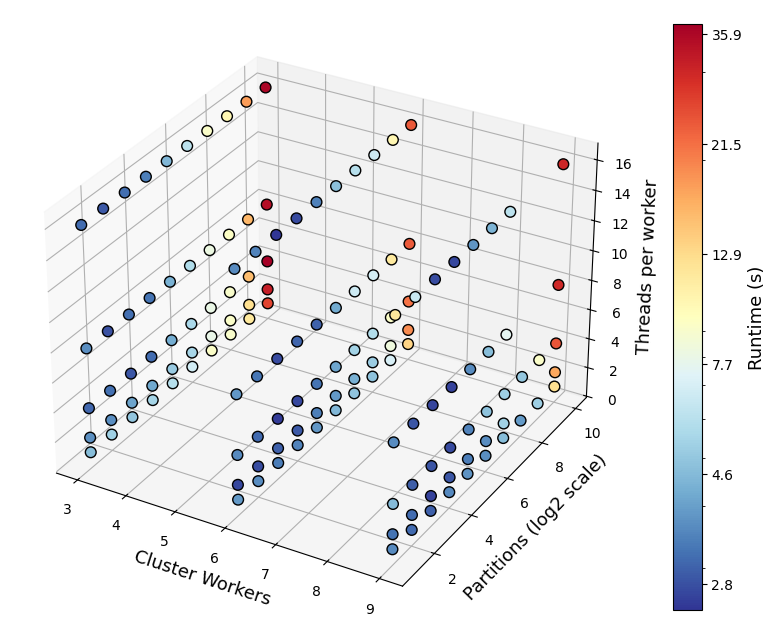

In [66]:
three_d_plot(benchmarking_results,"first_processing")

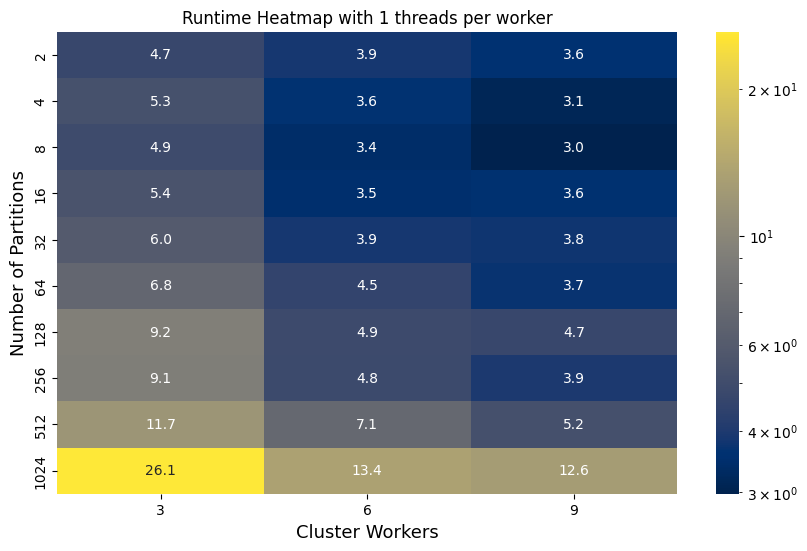

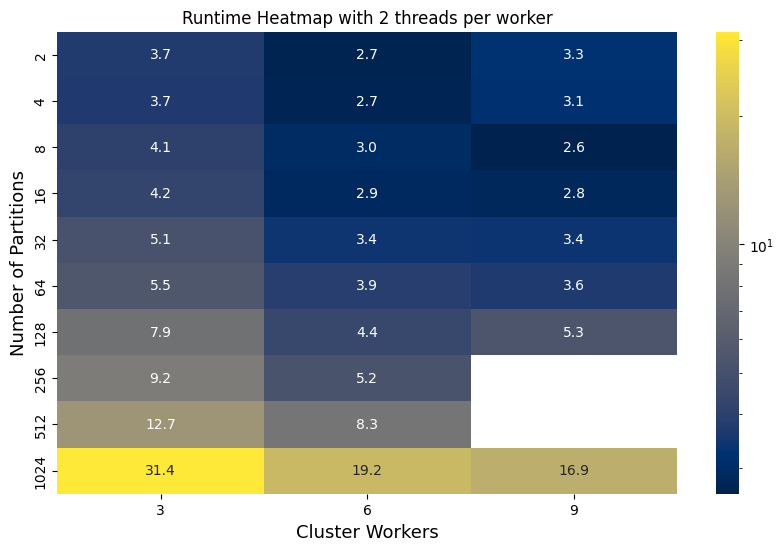

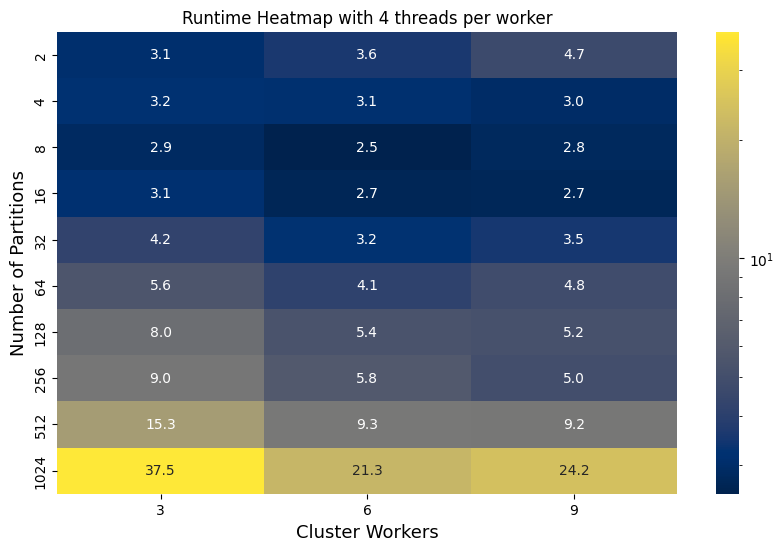

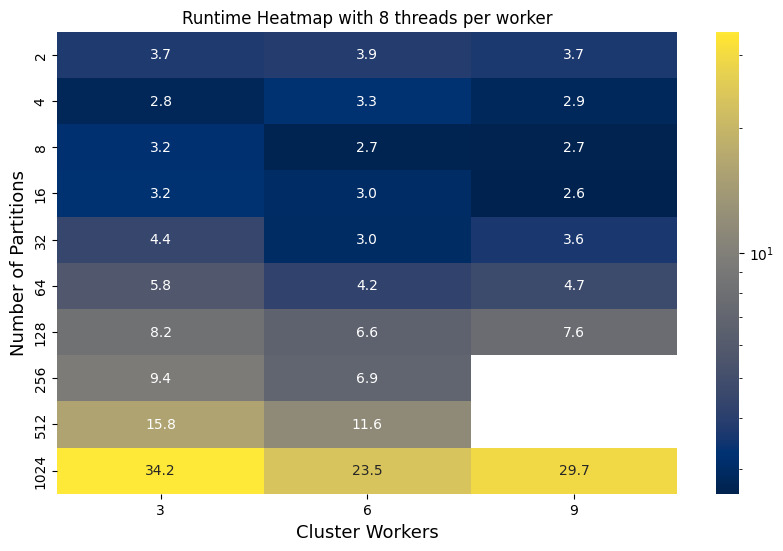

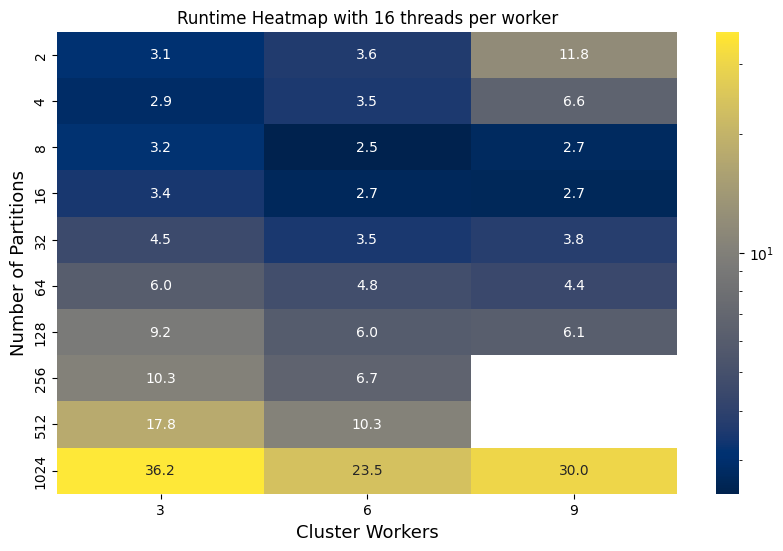

In [85]:
for thread in [1,2,4,8,16]: 
    heatmap_fixed_threads(benchmarking_results,"first_processing",thread)
    print("\n")
    

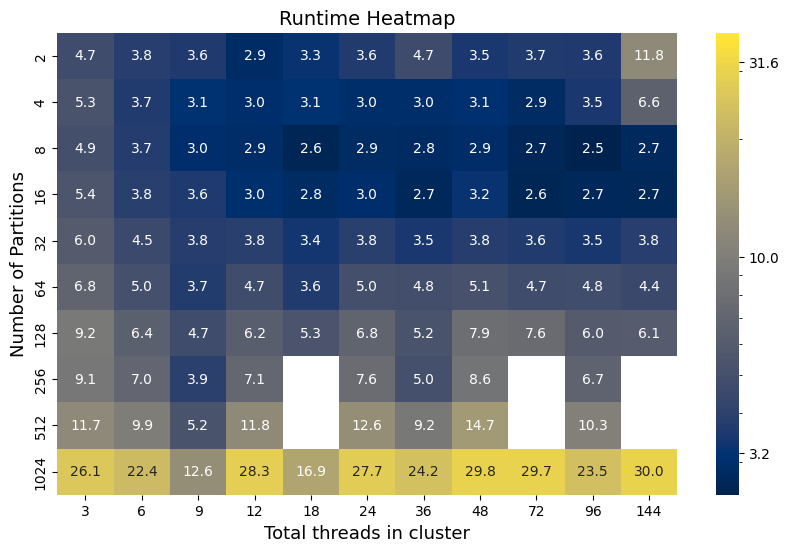

In [22]:
heatmap_total_threads(benchmarking_results,"first_processing")

## Local track Fit

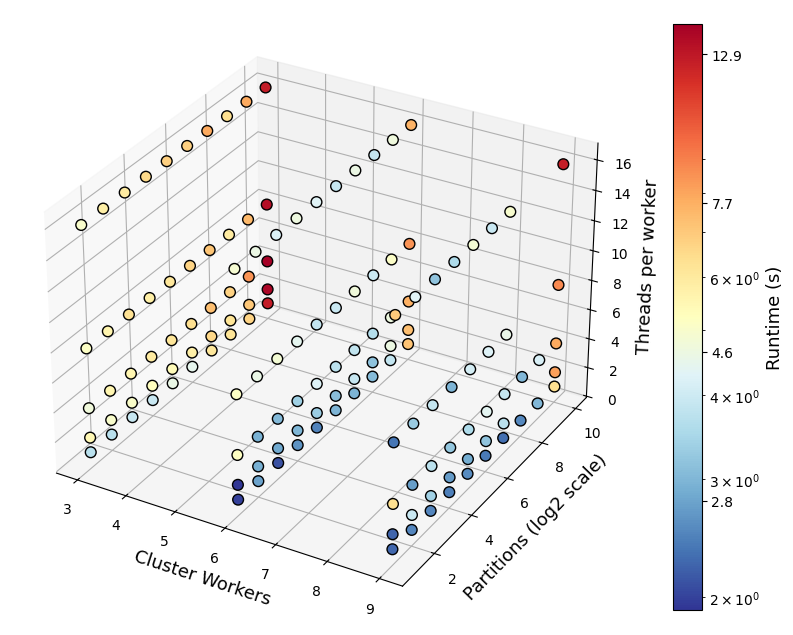

In [24]:
three_d_plot(benchmarking_results,"local_fit")

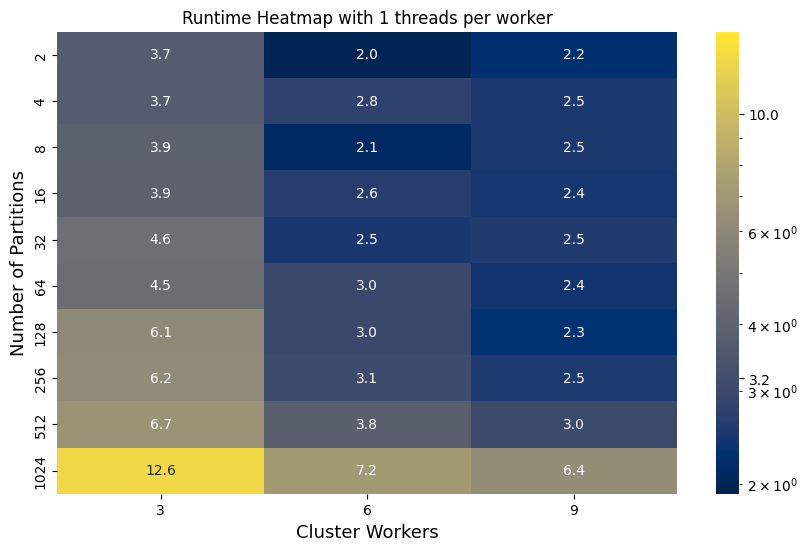

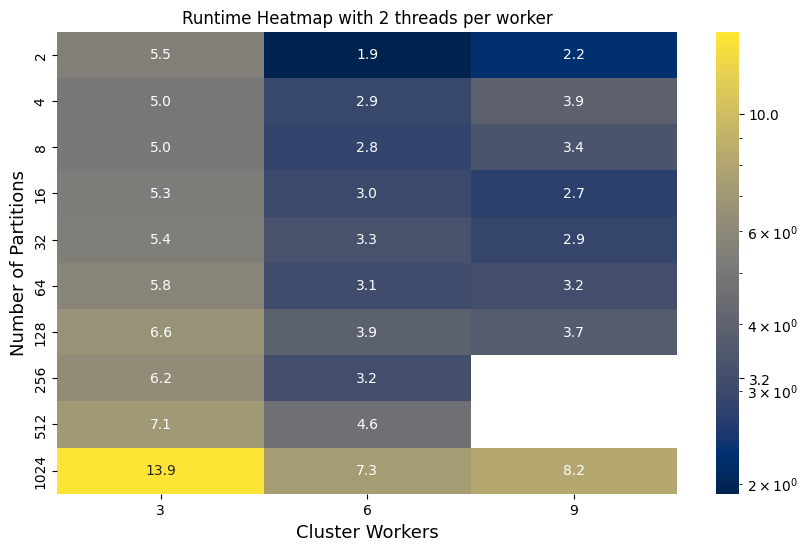

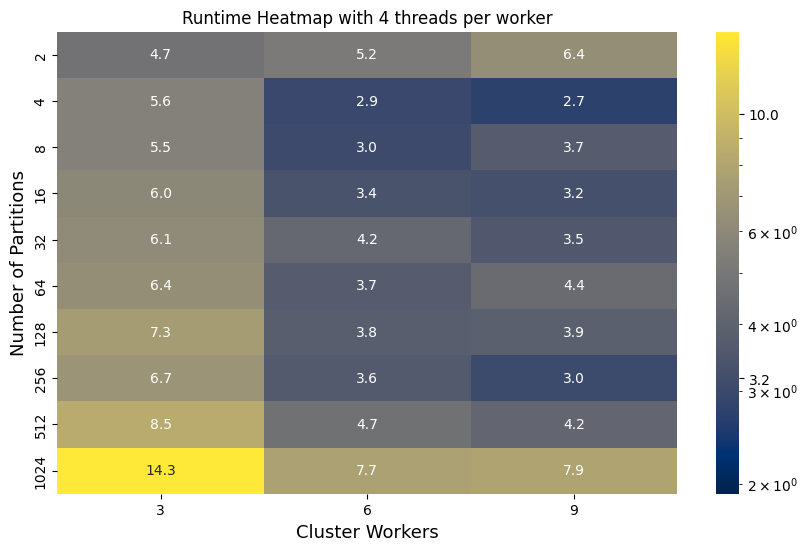

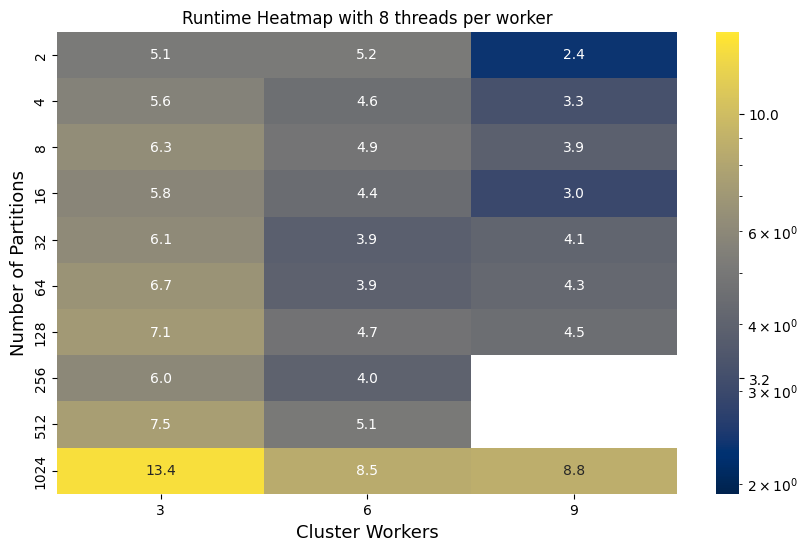

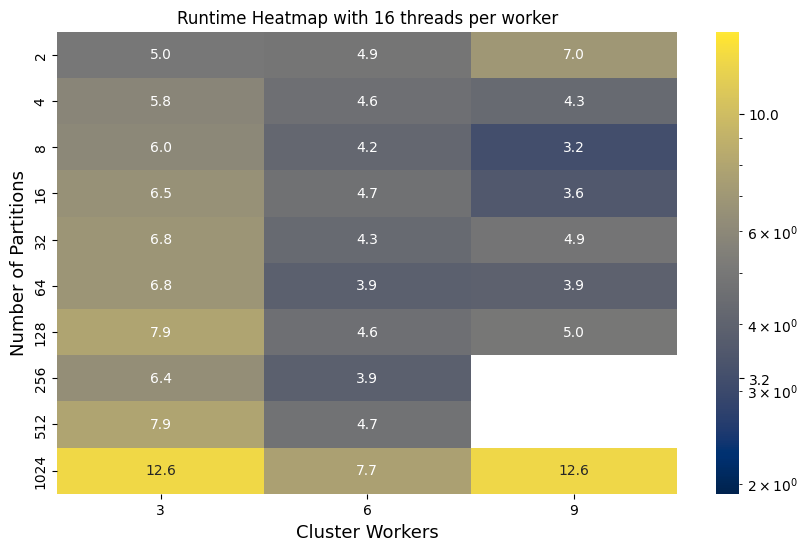

In [43]:
for thread in [1,2,4,8,16]: 
    heatmap_fixed_threads(benchmarking_results,"local_fit",thread)
    print("\n")
    

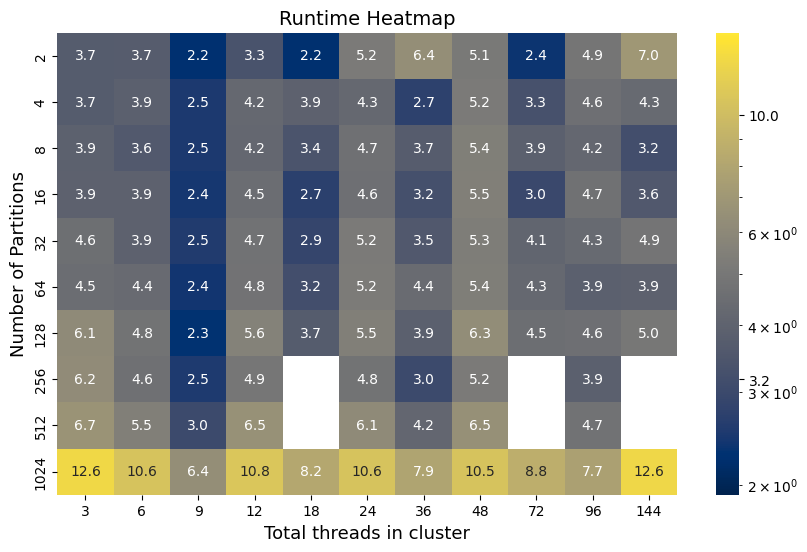

In [23]:
heatmap_total_threads(benchmarking_results,"local_fit")

## Global track Fit

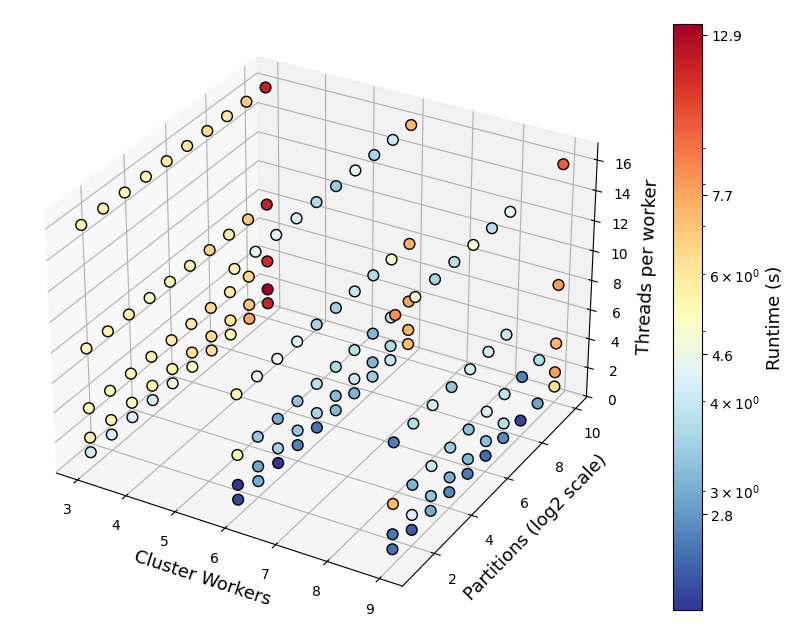

In [25]:
three_d_plot(benchmarking_results,"global_fit")

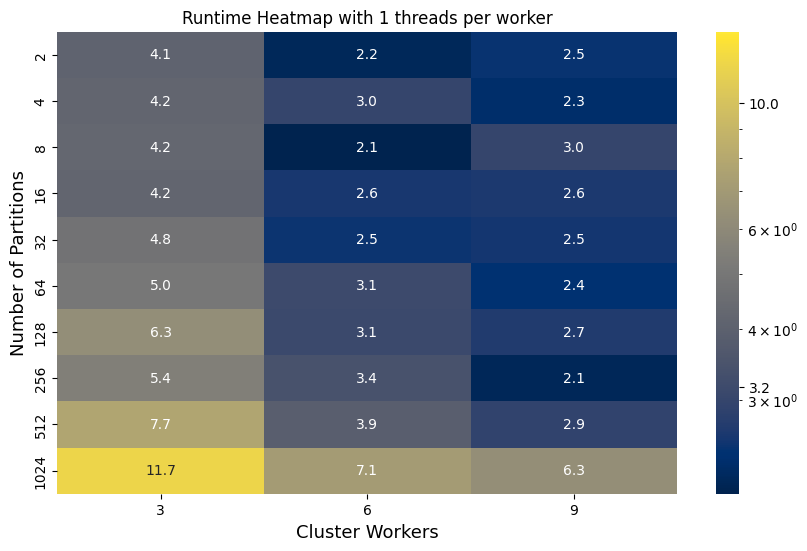

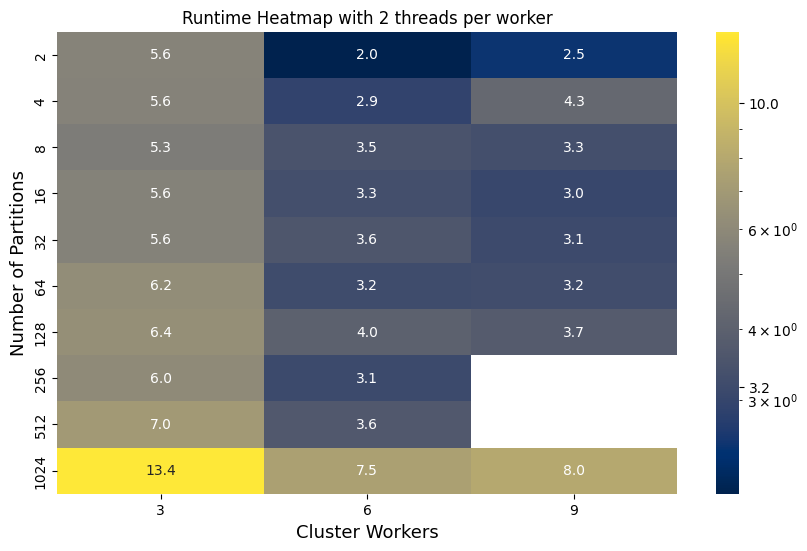

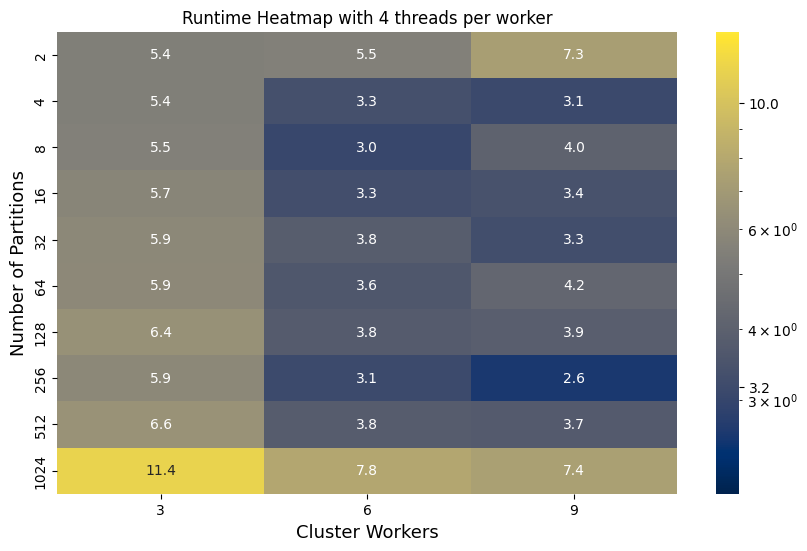

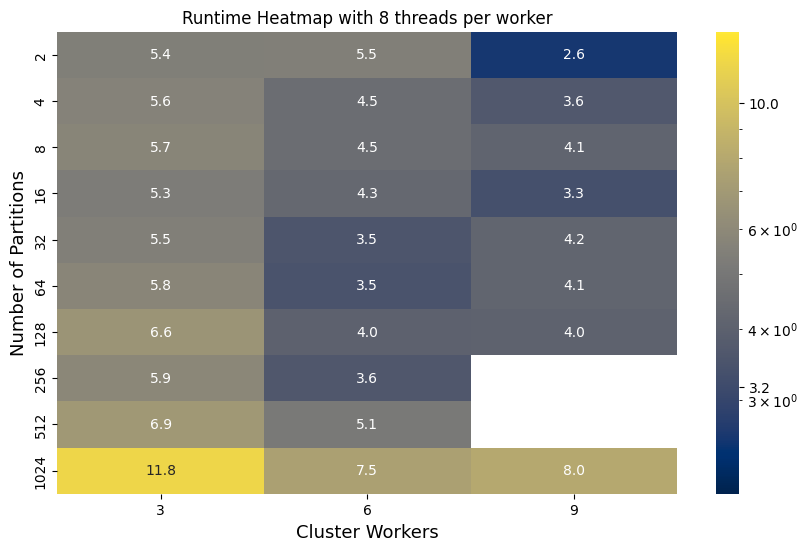

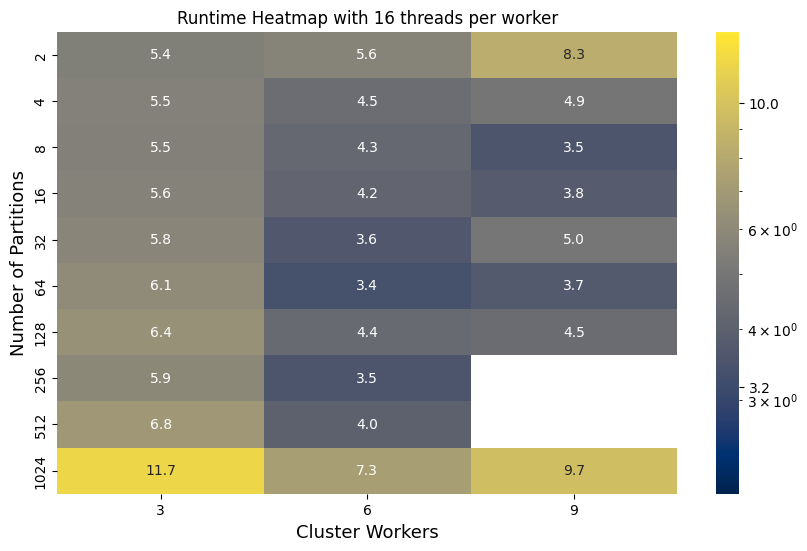

In [42]:
for thread in [1,2,4,8,16]: 
    heatmap_fixed_threads(benchmarking_results,"global_fit",thread)
    print("\n")

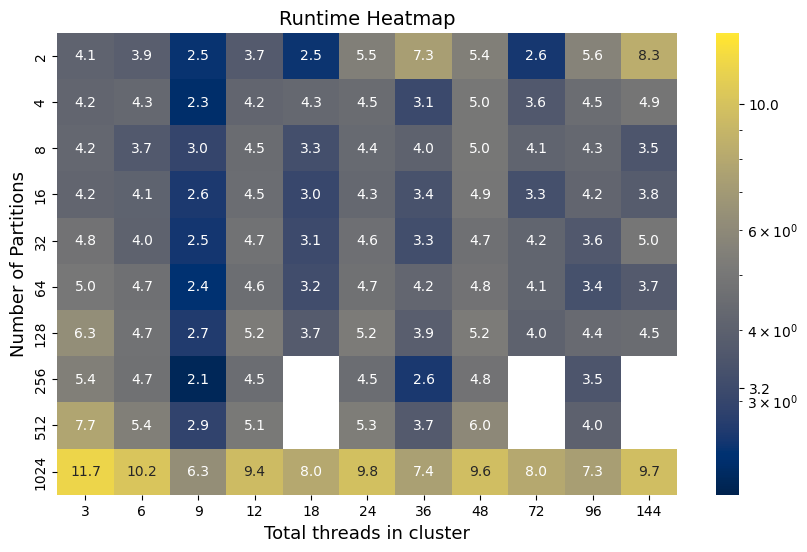

In [37]:
heatmap_total_threads(benchmarking_results,"global_fit")

## Angular resolution

Since the dataframe to handle is very small, we expect that the best choice is to perform a local computation (worse results with more workers and partitions).  

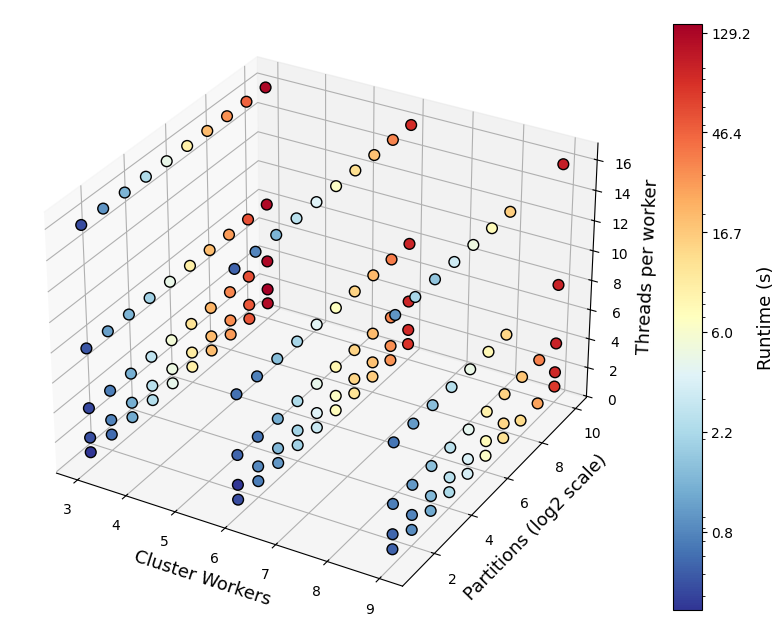

In [49]:
three_d_plot(benchmarking_results,"angular_resolution")

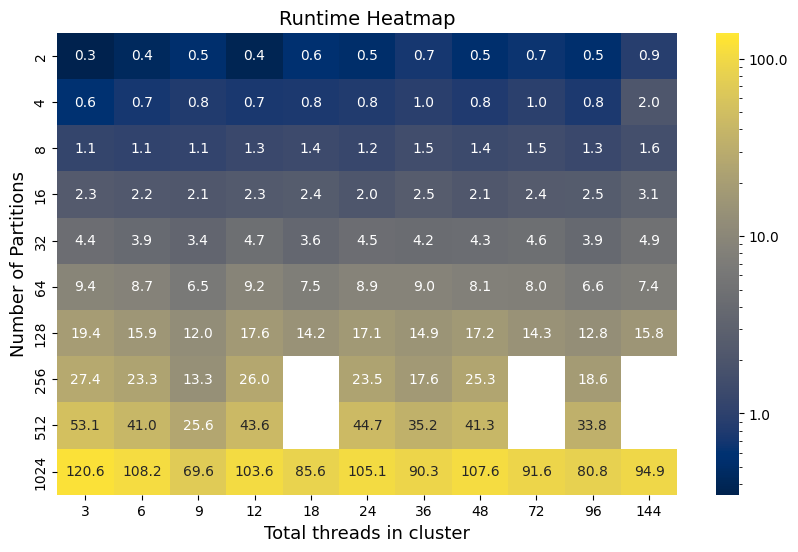

In [51]:
heatmap_total_threads(benchmarking_results,"angular_resolution")

## Total wall time

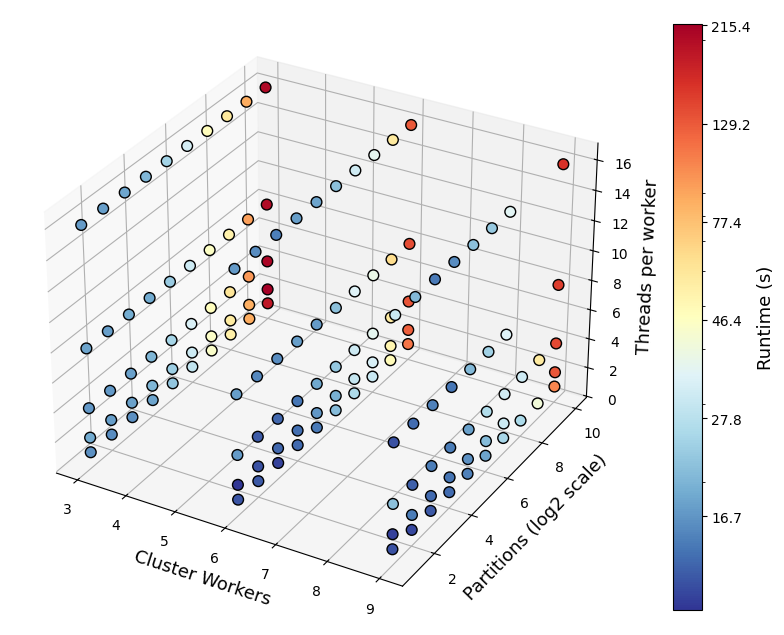

In [45]:
three_d_plot(benchmarking_results,"total_wall_time")

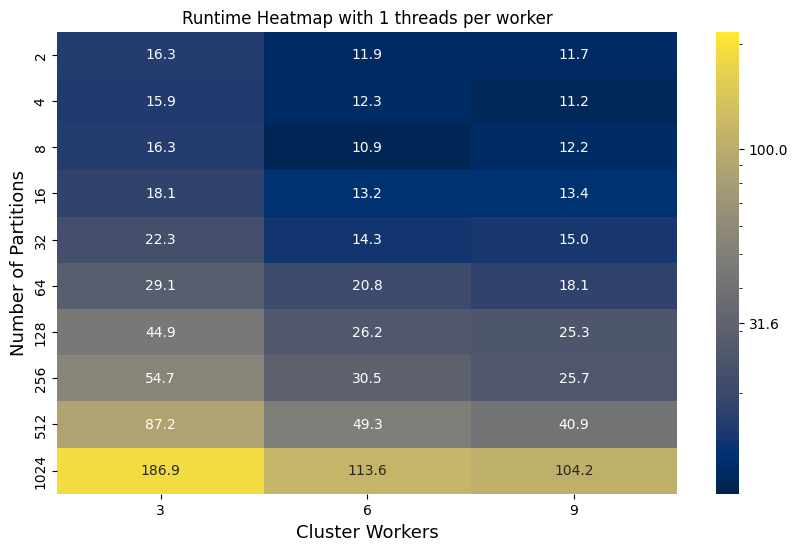

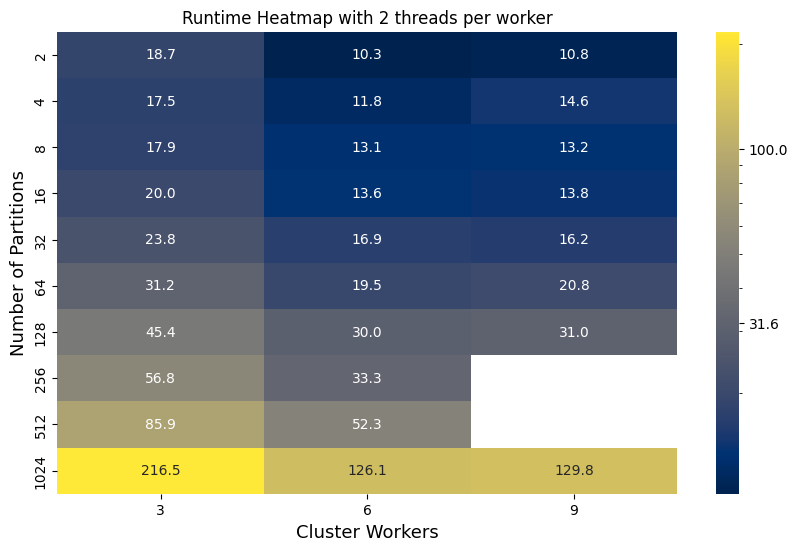

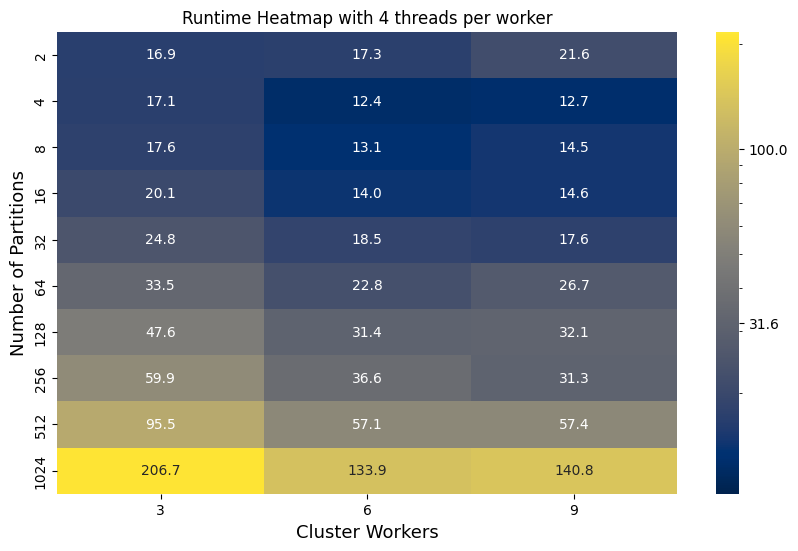

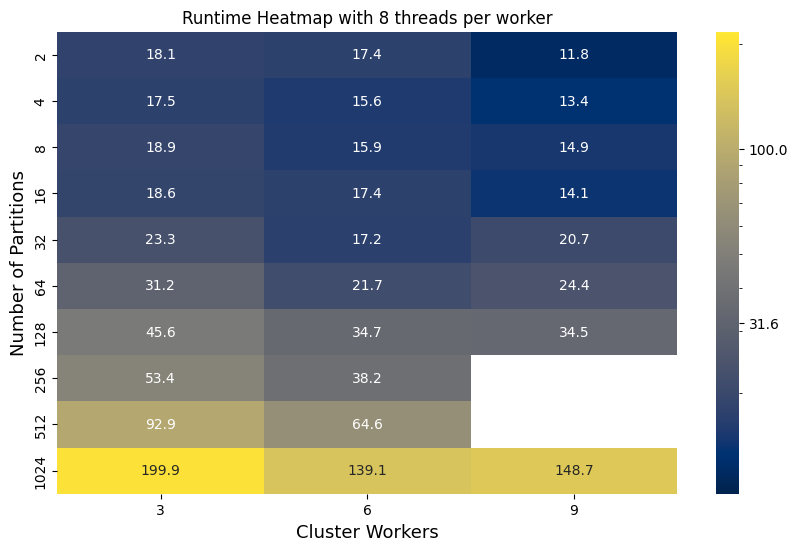

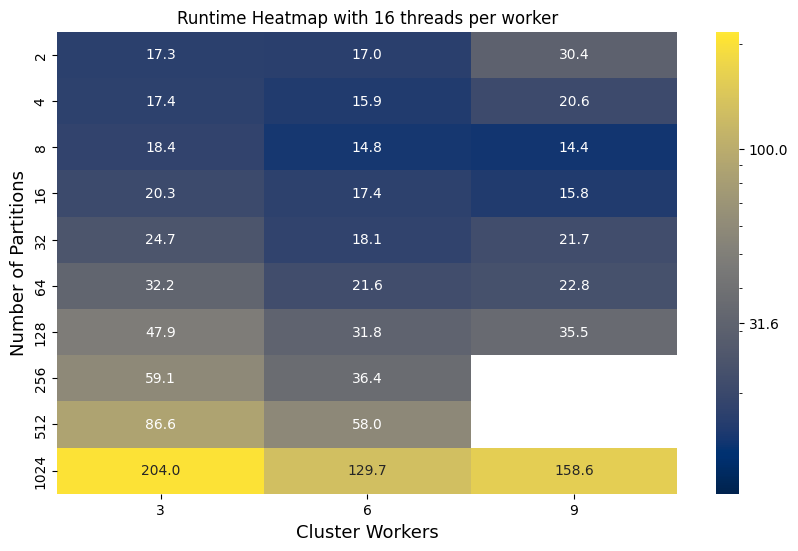

In [46]:
for thread in [1,2,4,8,16]: 
    heatmap_fixed_threads(benchmarking_results,"total_wall_time",thread)
    print("\n")

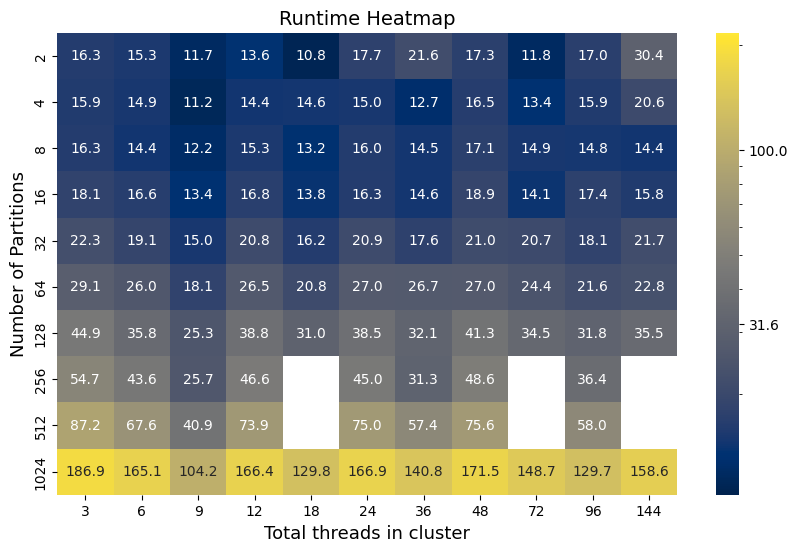

In [47]:
heatmap_total_threads(benchmarking_results,"total_wall_time")